In [222]:
%pip install matplotlib numpy scikit-learn pandas --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [223]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
# import sklearn.datasets
import pandas as pd
import numpy as np

# Task 1 Implement Logistic Regression

In [160]:
# Prediction function
def predict(Xi, W, b):
    z = np.dot(Xi, W) + b
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

In [187]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # TODO: This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            print("Average cost function over epoch:", J_running / N)
            print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
            print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b

# Task 2 Implement Logistic Regression

- Read both files
- Split train(70), test(15), validation(15)
- Train logistic regressor and check performance
- Scatter plot of results

In [159]:
# Reading data function
def read_data(file_path):
    df = pd.read_csv(file_path)
    y = df['Class'].values   # Labels
    X = df.drop('Class', axis=1).values  # Features
    return X, y

In [185]:
def split_data(X, y, train_ratio=0.7, test_ratio=0.15, validation_ratio=0.15, random_state=1):
    # https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    X_train, X_test_pre, y_train, y_test_pre = sklearn.model_selection.train_test_split(
    X, y, train_size=train_ratio, random_state=random_state)
    
    X_test, X_val, y_test, y_val = sklearn.model_selection.train_test_split(
    X_test_pre, y_test_pre, train_size=test_ratio/(test_ratio + validation_ratio), random_state=random_state)
    
    return X_train, y_train, X_test, y_test, X_val, y_val

## Blobs 600 dataset

In [ ]:
file_path = 'Datasets/blobs600.csv'
# file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=10000, threshold=1e-4)
print("Trained Weights:", W_trained)
print("Trained Bias:", b_trained)

Average cost function over epoch: [0.20070638]
Epoch: 1  Cost: [120.42382617]  Previous Cost: 0
Difference in cost function: [120.42382617]
Average cost function over epoch: [0.06952714]
Epoch: 2  Cost: [41.7162827]  Previous Cost: [120.42382617]
Difference in cost function: [78.70754347]
Average cost function over epoch: [0.04662904]
Epoch: 3  Cost: [27.97742576]  Previous Cost: [41.7162827]
Difference in cost function: [13.73885694]
Average cost function over epoch: [0.04222669]
Epoch: 4  Cost: [25.33601692]  Previous Cost: [27.97742576]
Difference in cost function: [2.64140884]
Average cost function over epoch: [0.03513247]
Epoch: 5  Cost: [21.07948292]  Previous Cost: [25.33601692]
Difference in cost function: [4.256534]
Average cost function over epoch: [0.02867501]
Epoch: 6  Cost: [17.20500591]  Previous Cost: [21.07948292]
Difference in cost function: [3.87447701]
Average cost function over epoch: [0.0281991]
Epoch: 7  Cost: [16.9194573]  Previous Cost: [17.20500591]
Difference 

In [202]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.9976190476190476
Test Accuracy: 0.9888888888888889
Validation Accuracy: 1.0


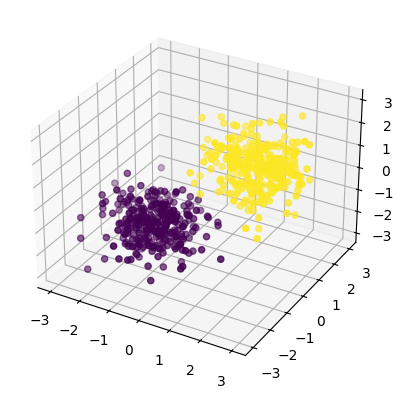

In [ ]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[:, 0], X_all[:, 1], X_all[:, 2], c=y_pred_all)

## Circles 500 dataset

In [219]:
# file_path = 'Datasets/blobs600.csv'
file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
W = np.random.normal(0,0.01,X.shape[1])
b = np.random.normal(0,0.01,1)

# Training the model using Stochastic Gradient Descent
W_trained, b_trained = stochastic_gradient_descent(X, y, W, b, alpha=1e-4, max_iters=10000, threshold=1e-8)
print("Trained Weights:", W_trained)
print("Trained Bias:", b_trained)

Average cost function over epoch: [0.69297535]
Epoch: 1  Cost: [346.4876768]  Previous Cost: 0
Difference in cost function: [346.4876768]
Average cost function over epoch: [0.69329909]
Epoch: 2  Cost: [346.64954433]  Previous Cost: [346.4876768]
Difference in cost function: [0.16186753]
Average cost function over epoch: [0.69351538]
Epoch: 3  Cost: [346.75768795]  Previous Cost: [346.64954433]
Difference in cost function: [0.10814362]
Average cost function over epoch: [0.69322172]
Epoch: 4  Cost: [346.61085897]  Previous Cost: [346.75768795]
Difference in cost function: [0.14682899]
Average cost function over epoch: [0.69315284]
Epoch: 5  Cost: [346.57642086]  Previous Cost: [346.61085897]
Difference in cost function: [0.0344381]
Average cost function over epoch: [0.69337973]
Epoch: 6  Cost: [346.6898649]  Previous Cost: [346.57642086]
Difference in cost function: [0.11344404]
Average cost function over epoch: [0.69306844]
Epoch: 7  Cost: [346.53421843]  Previous Cost: [346.6898649]
Di

In [220]:
treshold = 0.5

y_hat_train = predict(X_train, W_trained, b_trained)
y_pred_train = (y_hat_train >= treshold).astype(int)

y_hat_test = predict(X_test, W_trained, b_trained)
y_pred_test = (y_hat_test >= treshold).astype(int)

y_hat_val = predict(X_val, W_trained, b_trained)
y_pred_val = (y_hat_val >= treshold).astype(int)

accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_val = np.mean(y_pred_val == y_val)
print("Train Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)
print("Validation Accuracy:", accuracy_val)

Train Accuracy: 0.5228571428571429
Test Accuracy: 0.4533333333333333
Validation Accuracy: 0.5333333333333333


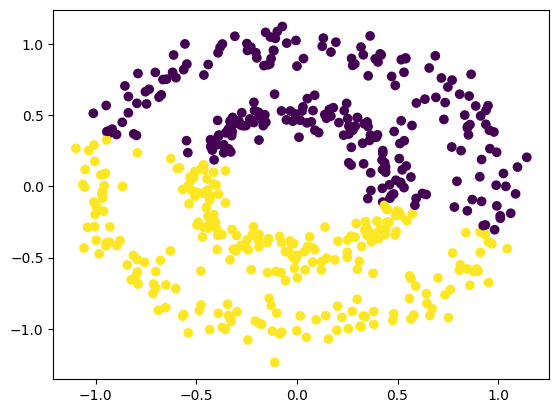

In [221]:
# Scatter plot of test results
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array
X_all = np.vstack((X_train, X_test, X_val))
y_pred_all = np.hstack((y_pred_train, y_pred_test, y_pred_val))

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X_all[:, 0], X_all[:, 1], c=y_pred_all)

# Task 3: Implement and Test a Shallow Neural Network

- 1 hidden layer
- 1 output node
- Support different number of inputs and different number of nodes in the hidden layer

- Test previous datasets with different number of nodes in the hidden layer
- Measure performance

In [402]:
def parameter_initialization(X, neurons_hidden_layer):
    np.random.seed(3301)
    W1 = np.random.normal(0,0.01,size=(neurons_hidden_layer,X.shape[1]))
    W2 = np.random.normal(0,0.01,size=(1,neurons_hidden_layer))
    W = [W1, W2]

    b1 = np.random.normal(0,0.01,size=(neurons_hidden_layer))
    b2 = np.random.normal(0,0.01,size=(1))
    b = [b1, b2]
    
    # https://numpy.org/devdocs/reference/generated/numpy.zeros.html
    z1 = np.zeros(shape=(neurons_hidden_layer))
    z2 = np.zeros(shape=(1))
    z = [z1, z2]
    a0 = np.zeros(shape=(X.shape[1]))
    a1 = np.zeros(shape=(neurons_hidden_layer))
    a2 = np.zeros(shape=(1))
    a = [a0, a1, a2]

    return W, b, z, a

In [418]:
# Forward propagation function
def forward_propagation(Xi, W, b, z, a):
   # X[observation][feature] 
   # W[layer][destination_node][source_node]
   # b[layer][destination_node]
   # z[layer][destination_node]
   # a[layer][destination_node]
   a[0] = Xi # Inputs are activations of layer 0
   for layer in range(1, 3):
      for destination_node in range(1, len(z[layer-1])+1):
         # Linear transformation 
         z[layer-1][destination_node-1] = np.dot(a[layer-1], W[layer-1][destination_node-1]) + b[layer-1][destination_node-1]
         # Activation function (Using logistic function)
         a[layer][destination_node-1] = 1 / (1 + np.exp(-z[layer-1][destination_node-1]))

   y_hat = a[layer][destination_node-1] # Output of the last layer is the prediction
   return y_hat, a, z

In [ ]:
# Stochastic Gradient Descent function
def stochastic_gradient_descent(X, y, W, b, alpha=0.01, max_iters=1000, threshold=1e-4):
    # TODO: Stop with the average cost function change less than threshold
    # TODO: This version does not have loops on backpropagation because it is for just one neuron
    N = X.shape[0]
    stopping = False
    J_running = 0
    J_running_prev = 0
    iteration = 0

    while not stopping:
        # Randomly select one data point #Sample size = 1        
        i_random = np.random.randint(0, high=N)
        y_hat = predict(X[i_random], W, b)
        J_current = - (y[i_random] * np.log(y_hat) + (1 - y[i_random]) * np.log(1 - y_hat))
        error = y_hat - y[i_random]
        
        delta_W = error * X[i_random]
        delta_b = error
        
        W -= alpha * delta_W
        b -= alpha * delta_b

        # Check stopping criteria
        iteration += 1
        J_running += J_current
        if iteration >= max_iters:
            stopping = True
        if iteration % N == 0:
            print("Average cost function over epoch:", J_running / N)
            print("Epoch:", iteration // N, " Cost:", J_running, " Previous Cost:", J_running_prev)
            print("Difference in cost function:", abs(J_running - J_running_prev))
            if abs(J_running - J_running_prev) < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0
        
    return W, b

In [421]:
file_path = 'Datasets/blobs600.csv'
# file_path = 'Datasets/circles500.csv'
X, y = read_data(file_path)
# Split data into training, testing, and validation sets
X_train, y_train, X_test, y_test, X_val, y_val = split_data(X, y)
# Initialize weights and bias
np.random.seed(3301)
neurons_hidden_layer = 5
W, b, z, a = parameter_initialization(X, neurons_hidden_layer=neurons_hidden_layer)

# Simple forward propagation test
# y_hat, a, z = forward_propagation(X_train[0], W, b, z, a)


In [420]:
a

[array([ 0.49089858, -1.95722502, -0.91311212]),
 array([0.51079334, 0.4978573 , 0.49068735, 0.50478001, 0.50968956]),
 array([0.49985213])]

In [400]:
y_hat

np.float64(0.4998757137296071)

In [401]:
a

[array([-1.14393346, -0.65741051, -1.45661219]),
 array([0.50661135, 0.48682911, 0.49963055, 0.50486675, 0.50550199]),
 array([0.49987571])]

In [390]:
W

[array([[-0.00563357, -0.02073575, -0.00185757],
        [ 0.02007814, -0.00349973,  0.0124223 ],
        [-0.00999929,  0.01745885,  0.0060043 ],
        [-0.00707935, -0.01188298, -0.00776281],
        [ 0.00468337, -0.01143027, -0.01059705]]),
 array([[ 0.0037186 , -0.01687134, -0.00743242,  0.00366145,  0.00239738]])]